# FFT & Power Spectral Density — Visual Demo

このノートブックは **TEM ノイズ解析**（nb03）を理解するために必要な周波数領域の直感を養います。

TEM 画像のノイズは「周波数成分」が重要です。ショットノイズは白色（フラットなスペクトル）ですが、
読み出し回路やドリフトによるアーティファクトは有色成分を導入します。
**パワースペクトル密度 (PSD)** とその動径平均が、nb03 でノイズを特徴づけ再現するための中心的なツールです。

**学習の流れ**

| セクション | 内容 |
|-----------|------|
| 1 | 1D FFT：単一正弦波 → 重ね合わせ → ノイズの影響 |
| 2 | 2D FFT：向きの異なる縞模様 |
| 3 | パワースペクトル密度 (PSD)：白色 vs 有色ノイズ |
| 4 | 動径 PSD：nb03 で使う 1D サマリ |

In [11]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

---
## セクション 1: 1D FFT

**離散フーリエ変換 (DFT)** は信号 $f(x)$ を複素指数関数の重ね合わせに分解します：

$$F(k) = \sum_{x=0}^{N-1} f(x)\, e^{-2\pi i k x / N}$$

- $x$ — 空間（または時間）インデックス
- $k$ — 周波数ビン（サンプルあたりのサイクル数）
- $|F(k)|$ — 周波数 $k$ における**振幅**

周波数 $f_0$ の純粋な正弦波はスペクトルにちょうど 2 本のスパイク（$\pm f_0$）を生じます。  
正弦波の重ね合わせは各成分に対応するスパイクを生じます。  
ノイズはすべての周波数にパワーを分散させます。

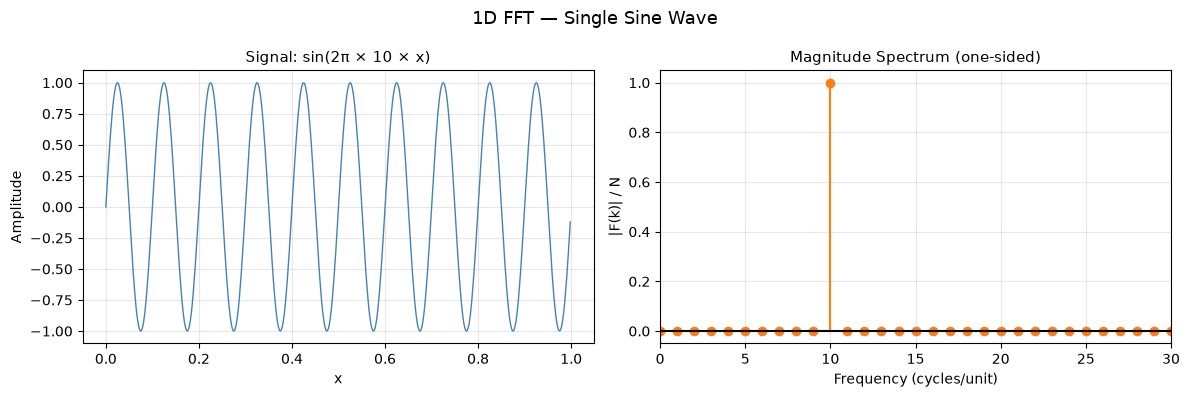

In [12]:
# --- Single sine wave ---
N  = 512
x  = np.linspace(0, 1, N, endpoint=False)
f0 = 10          # Hz (cycles per unit length)
y  = np.sin(2 * np.pi * f0 * x)

Y    = np.fft.fft(y)
freq = np.fft.fftfreq(N, d=x[1] - x[0])   # cycles per unit

# Keep only positive frequencies for display
half = N // 2
mag  = np.abs(Y[:half]) * 2 / N            # one-sided, amplitude-normalised

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x, y, color='steelblue', lw=1)
axes[0].set_title(f'Signal: sin(2π × {f0} × x)', fontsize=11)
axes[0].set_xlabel('x')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

axes[1].stem(freq[:half], mag, linefmt='C1-', markerfmt='C1o', basefmt='k-')
axes[1].set_title('Magnitude Spectrum (one-sided)', fontsize=11)
axes[1].set_xlabel('Frequency (cycles/unit)')
axes[1].set_ylabel('|F(k)| / N')
axes[1].set_xlim(0, 30)
axes[1].grid(True, alpha=0.3)

fig.suptitle('1D FFT — Single Sine Wave', fontsize=13)
plt.tight_layout()
plt.show()

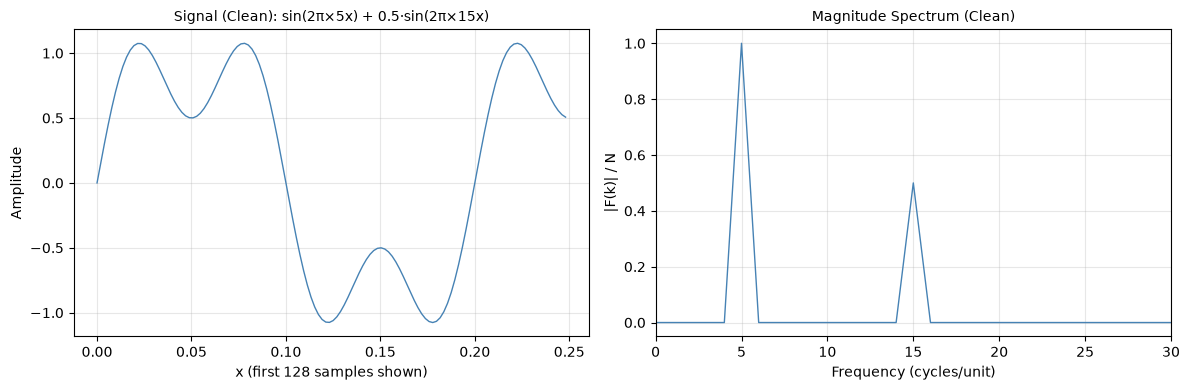

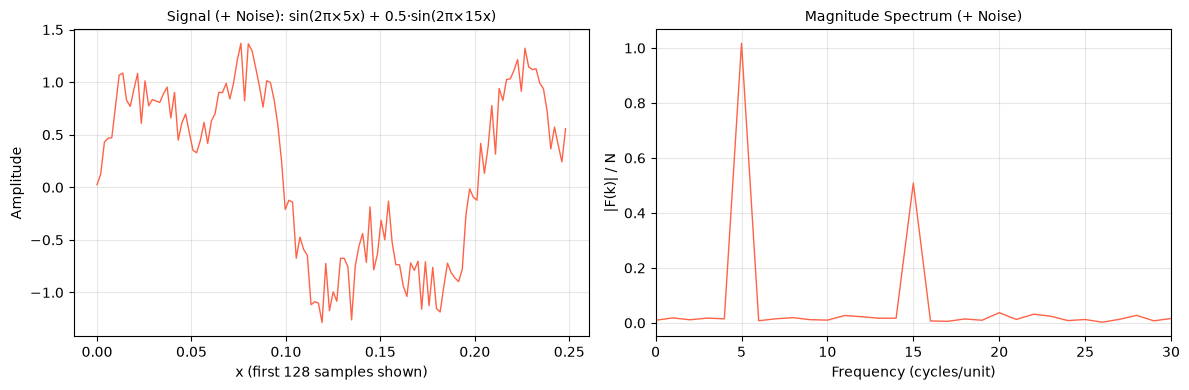

Observation: noise raises the spectral floor between the two peaks.


In [13]:
# --- Superposition of two sines + weak noise ---
rng = np.random.default_rng(0)

y_clean = np.sin(2 * np.pi * 5  * x) + 0.5 * np.sin(2 * np.pi * 15 * x)
y_noisy = y_clean + 0.2 * rng.standard_normal(N)

for label, sig, color in [('Clean', y_clean, 'steelblue'), ('+ Noise', y_noisy, 'tomato')]:
    Y_   = np.fft.fft(sig)
    mag_ = np.abs(Y_[:half]) * 2 / N

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(x[:128], sig[:128], color=color, lw=1)
    axes[0].set_title(f'Signal ({label}): sin(2π×5x) + 0.5·sin(2π×15x)', fontsize=10)
    axes[0].set_xlabel('x (first 128 samples shown)')
    axes[0].set_ylabel('Amplitude')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(freq[:half], mag_, color=color, lw=1)
    axes[1].set_title(f'Magnitude Spectrum ({label})', fontsize=10)
    axes[1].set_xlabel('Frequency (cycles/unit)')
    axes[1].set_ylabel('|F(k)| / N')
    axes[1].set_xlim(0, 30)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("Observation: noise raises the spectral floor between the two peaks.")

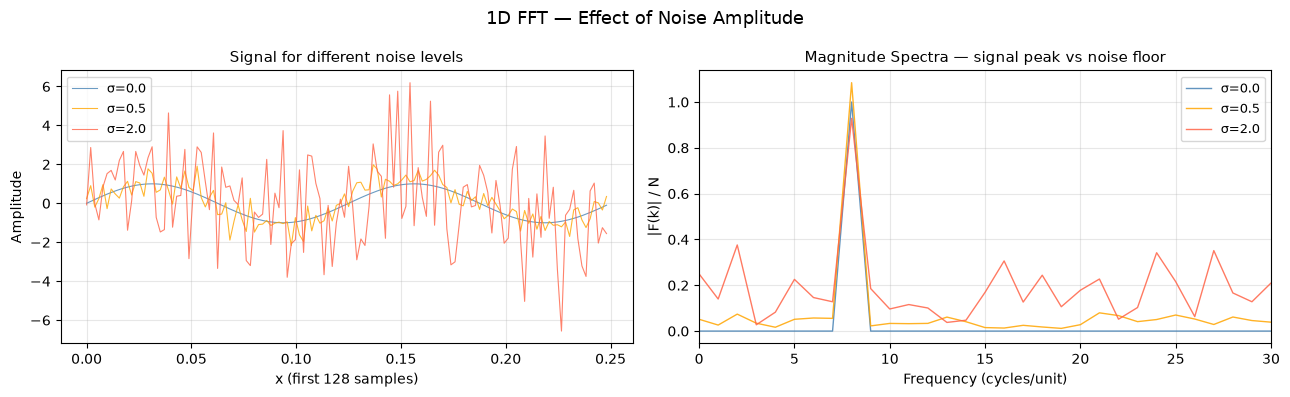

Key point: the peak at f=8 stays fixed; the spectral floor rises with σ.


In [14]:
# --- Effect of noise level on FFT spectrum ---
y_base = np.sin(2 * np.pi * 8 * x)

noise_levels = [0.0, 0.5, 2.0]
colors       = ['steelblue', 'orange', 'tomato']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for sigma, col in zip(noise_levels, colors):
    y_    = y_base + sigma * rng.standard_normal(N)
    Y_    = np.fft.fft(y_)
    mag_  = np.abs(Y_[:half]) * 2 / N
    axes[0].plot(x[:128], y_[:128], color=col, lw=0.8, alpha=0.8, label=f'σ={sigma}')
    axes[1].plot(freq[:half], mag_, color=col, lw=1, alpha=0.85, label=f'σ={sigma}')

axes[0].set_title('Signal for different noise levels', fontsize=11)
axes[0].set_xlabel('x (first 128 samples)')
axes[0].set_ylabel('Amplitude')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Magnitude Spectra — signal peak vs noise floor', fontsize=11)
axes[1].set_xlabel('Frequency (cycles/unit)')
axes[1].set_ylabel('|F(k)| / N')
axes[1].set_xlim(0, 30)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.suptitle('1D FFT — Effect of Noise Amplitude', fontsize=13)
plt.tight_layout()
plt.show()

print("Key point: the peak at f=8 stays fixed; the spectral floor rises with σ.")

---
## セクション 2: 2D FFT

2D 画像 $f(x,y)$ に対して DFT は次のように拡張されます：

$$F(k_x, k_y) = \sum_{x}\sum_{y} f(x,y)\, e^{-2\pi i (k_x x / M + k_y y / N)}$$

重要なポイント：
- **DC 成分**（$k_x=k_y=0$）= 画素の平均値。デフォルトでは隅に置かれ、`np.fft.fftshift` で中心に移動します。
- **水平縞**（$y$ 方向にのみ変化）→ エネルギーが**縦軸**（$k_x = 0$）に集中します。
- **垂直縞**（$x$ 方向にのみ変化）→ エネルギーが**横軸**（$k_y = 0$）に集中します。
- **斜め縞** → エネルギーが対応する対角線方向に現れます。
- 大きなダイナミックレンジを圧縮するため $\log(1 + |F|^2)$ で表示します。

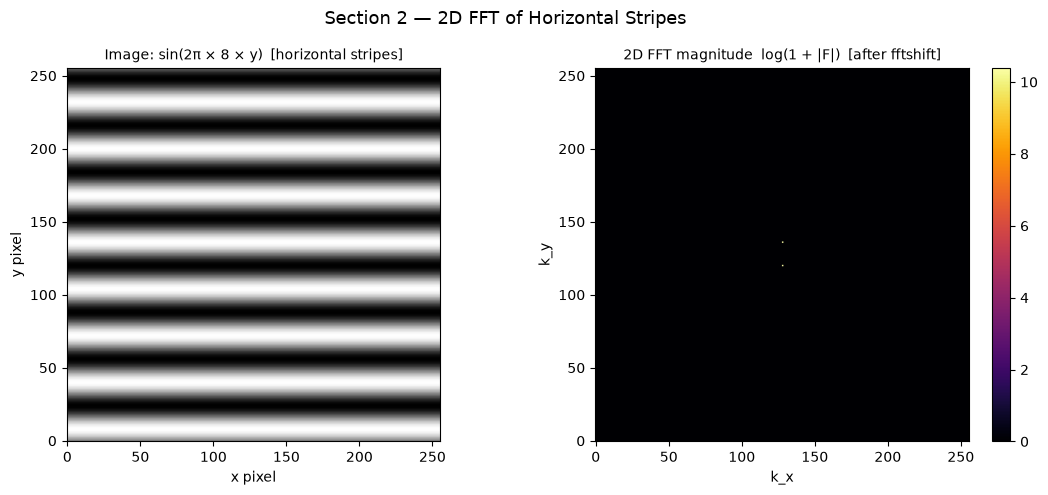

The two bright spots sit on the vertical axis (k_x = 0), at ±fy.


In [15]:
# --- Single 2D sine wave (horizontal stripes) ---
M = 256
xx, yy = np.meshgrid(np.linspace(0, 1, M, endpoint=False),
                     np.linspace(0, 1, M, endpoint=False))

fy  = 8      # cycles per unit length in y-direction
img = np.sin(2 * np.pi * fy * yy)    # horizontal stripes

FT      = np.fft.fft2(img)
FT_sh   = np.fft.fftshift(FT)
log_mag = np.log1p(np.abs(FT_sh))

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].imshow(img, cmap='gray', origin='lower')
axes[0].set_title(f'Image: sin(2π × {fy} × y)  [horizontal stripes]', fontsize=10)
axes[0].set_xlabel('x pixel')
axes[0].set_ylabel('y pixel')

im1 = axes[1].imshow(log_mag, cmap='inferno', origin='lower')
axes[1].set_title('2D FFT magnitude  log(1 + |F|)  [after fftshift]', fontsize=10)
axes[1].set_xlabel('k_x')
axes[1].set_ylabel('k_y')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

fig.suptitle('Section 2 — 2D FFT of Horizontal Stripes', fontsize=13)
plt.tight_layout()
plt.show()

print("The two bright spots sit on the vertical axis (k_x = 0), at ±fy.")

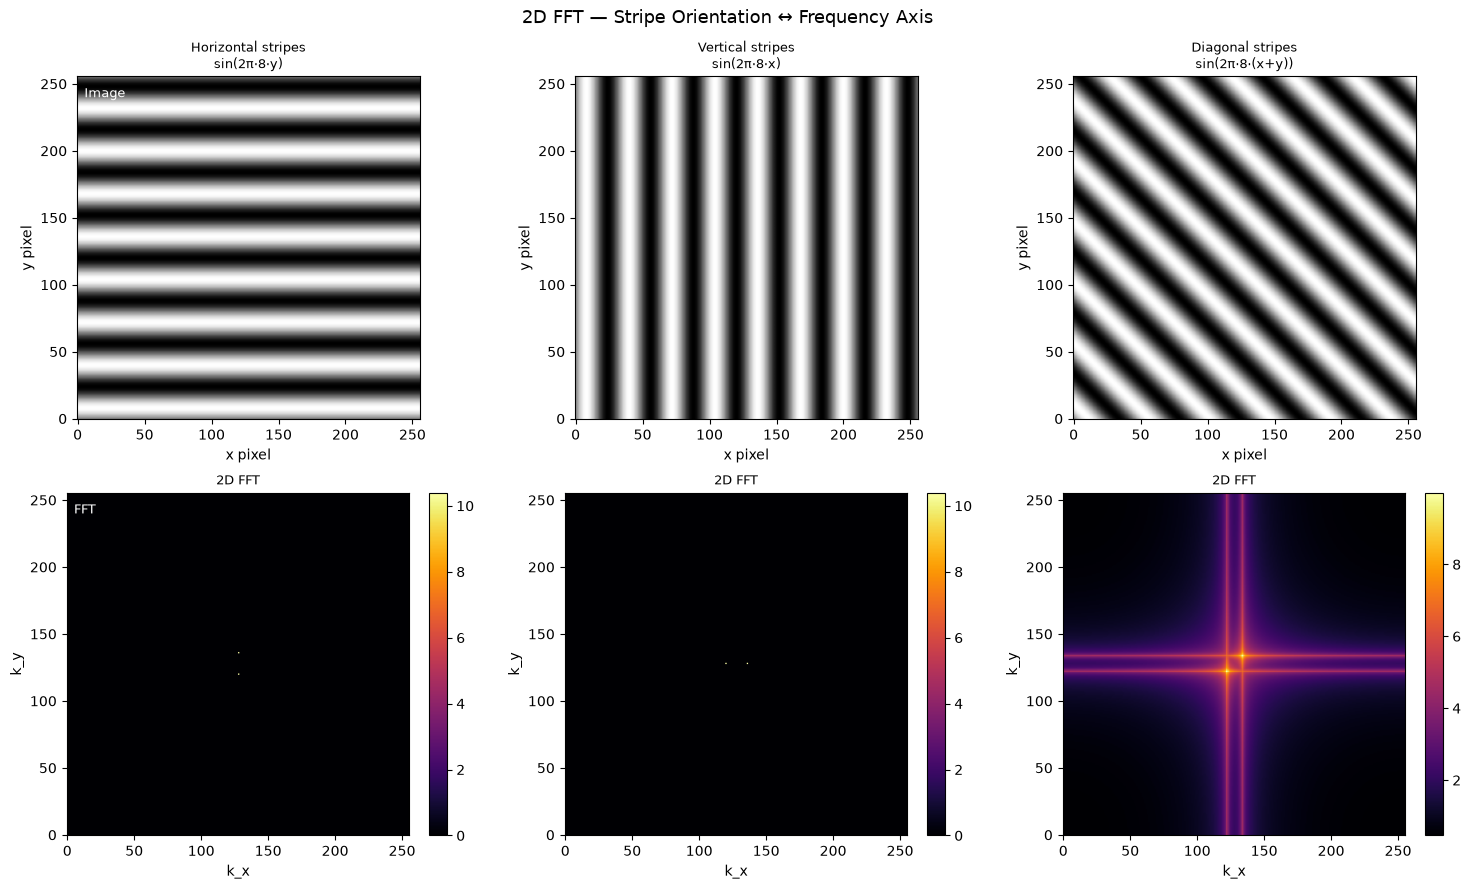

In [16]:
# --- Compare horizontal / vertical / diagonal stripes ---
f_stripe = 8
patterns = {
    'Horizontal stripes\nsin(2π·8·y)':  np.sin(2 * np.pi * f_stripe * yy),
    'Vertical stripes\nsin(2π·8·x)':    np.sin(2 * np.pi * f_stripe * xx),
    'Diagonal stripes\nsin(2π·8·(x+y))': np.sin(2 * np.pi * f_stripe * (xx + yy) / np.sqrt(2)),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for col, (title, img_) in enumerate(patterns.items()):
    FT_sh_  = np.fft.fftshift(np.fft.fft2(img_))
    log_m_  = np.log1p(np.abs(FT_sh_))

    axes[0, col].imshow(img_, cmap='gray', origin='lower')
    axes[0, col].set_title(title, fontsize=9)
    axes[0, col].set_xlabel('x pixel')
    axes[0, col].set_ylabel('y pixel')

    im = axes[1, col].imshow(log_m_, cmap='inferno', origin='lower')
    axes[1, col].set_title('2D FFT', fontsize=9)
    axes[1, col].set_xlabel('k_x')
    axes[1, col].set_ylabel('k_y')
    plt.colorbar(im, ax=axes[1, col], fraction=0.046)

axes[0, 0].text(5, 240, 'Image', fontsize=9, color='white')
axes[1, 0].text(5, 240, 'FFT',   fontsize=9, color='white')

fig.suptitle('2D FFT — Stripe Orientation ↔ Frequency Axis', fontsize=13)
plt.tight_layout()
plt.show()

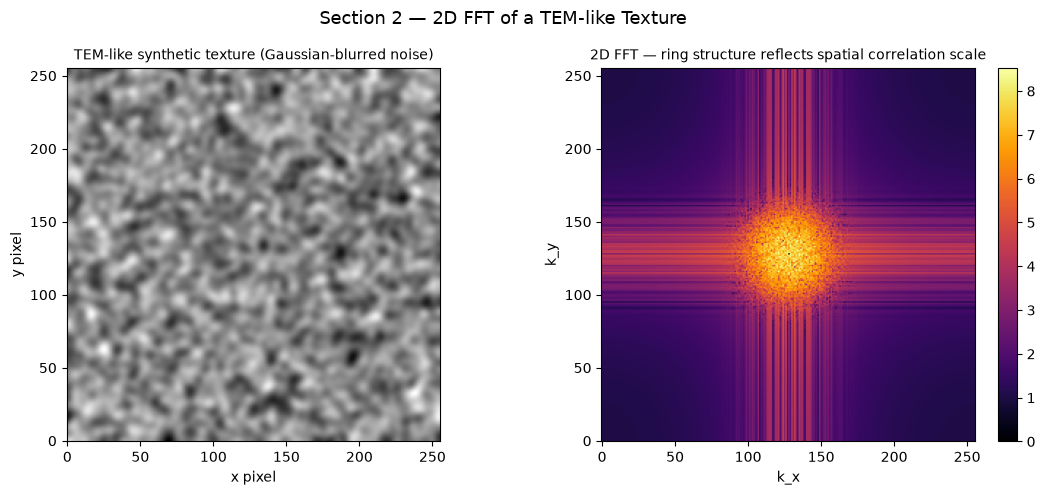

The FFT shows a central bright disk: most power is at low spatial frequencies.


In [17]:
# --- TEM-like synthetic image: random Gaussian texture ---
from scipy.ndimage import gaussian_filter

white_noise = rng.standard_normal((M, M))
tem_like    = gaussian_filter(white_noise, sigma=3)   # short-range correlated
tem_like    = (tem_like - tem_like.mean()) / tem_like.std()

FT_tem  = np.fft.fftshift(np.fft.fft2(tem_like))
log_tem = np.log1p(np.abs(FT_tem))

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].imshow(tem_like, cmap='gray', origin='lower')
axes[0].set_title('TEM-like synthetic texture (Gaussian-blurred noise)', fontsize=10)
axes[0].set_xlabel('x pixel')
axes[0].set_ylabel('y pixel')

im1 = axes[1].imshow(log_tem, cmap='inferno', origin='lower')
axes[1].set_title('2D FFT — ring structure reflects spatial correlation scale', fontsize=10)
axes[1].set_xlabel('k_x')
axes[1].set_ylabel('k_y')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

fig.suptitle('Section 2 — 2D FFT of a TEM-like Texture', fontsize=13)
plt.tight_layout()
plt.show()

print("The FFT shows a central bright disk: most power is at low spatial frequencies.")

---
## セクション 3: パワースペクトル密度 (PSD)

**パワースペクトル密度**は次のように定義されます：

$$\text{PSD}(k) = \frac{|F(k)|^2}{N}$$

各周波数ビンが持つ「パワー（分散）」の大きさを表します。  
**対数-対数スケール**でプロットすると、$1/f^\alpha$ ノイズのスペクトル傾き $\alpha$ が直線として現れます。

| ノイズの種類 | PSD の形状 | 例 |
|------------|-----------|-----|
| 白色ノイズ | フラット | ショットノイズ |
| ピンク / 1/f | 傾き −1（対数-対数） | 電子回路の 1/f ノイズ |
| ブラウン / 1/f² | 傾き −2（対数-対数） | 白色ノイズの積分 |

TEM 背景ノイズは一般に白色とピンクの間（$0 < \alpha < 2$）に位置します。

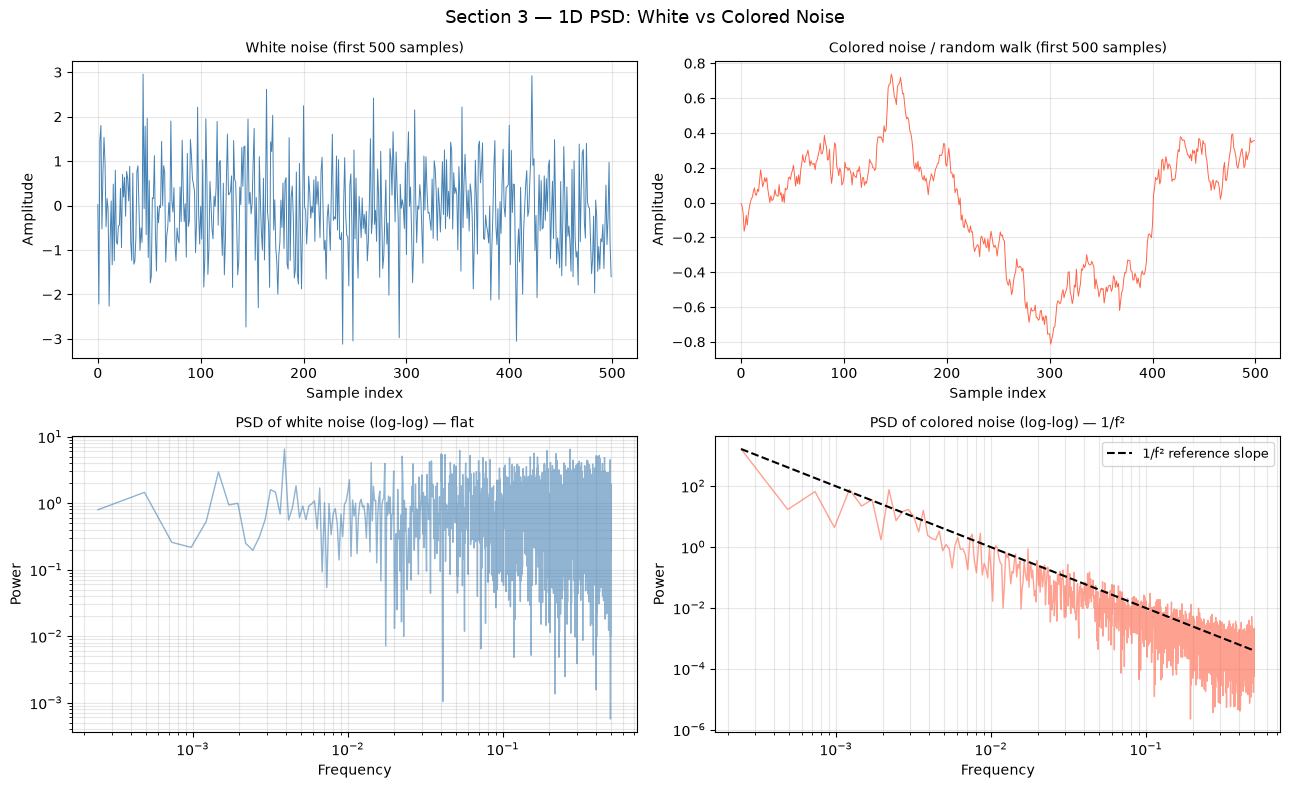

In [18]:
# --- 1D PSD: white noise vs colored (≈1/f) noise ---
N_psd  = 4096
white  = rng.standard_normal(N_psd)
colored = np.cumsum(rng.standard_normal(N_psd))   # random walk ≈ 1/f²
colored = colored / colored.std()

# PSD via FFT
def psd_1d(sig):
    N_  = len(sig)
    Y_  = np.fft.rfft(sig)
    psd = (np.abs(Y_) ** 2) / N_
    f_  = np.fft.rfftfreq(N_)
    return f_, psd

fw, pw   = psd_1d(white)
fc, pc   = psd_1d(colored)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Signals
axes[0, 0].plot(white[:500],   color='steelblue', lw=0.7, label='White noise')
axes[0, 0].set_title('White noise (first 500 samples)', fontsize=10)
axes[0, 0].set_xlabel('Sample index')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(colored[:500], color='tomato',    lw=0.7, label='Colored noise')
axes[0, 1].set_title('Colored noise / random walk (first 500 samples)', fontsize=10)
axes[0, 1].set_xlabel('Sample index')
axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].grid(True, alpha=0.3)

# PSDs on log-log
axes[1, 0].loglog(fw[1:], pw[1:], color='steelblue', lw=1, alpha=0.6)
axes[1, 0].set_title('PSD of white noise (log-log) — flat', fontsize=10)
axes[1, 0].set_xlabel('Frequency')
axes[1, 0].set_ylabel('Power')
axes[1, 0].grid(True, which='both', alpha=0.3)

axes[1, 1].loglog(fc[1:], pc[1:], color='tomato', lw=1, alpha=0.6)
# Reference slope −2
f_ref  = fc[1:]
axes[1, 1].loglog(f_ref, pc[1] * (f_ref[0] / f_ref) ** 2,
                  'k--', lw=1.5, label='1/f² reference slope')
axes[1, 1].set_title('PSD of colored noise (log-log) — 1/f²', fontsize=10)
axes[1, 1].set_xlabel('Frequency')
axes[1, 1].set_ylabel('Power')
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(True, which='both', alpha=0.3)

fig.suptitle('Section 3 — 1D PSD: White vs Colored Noise', fontsize=13)
plt.tight_layout()
plt.show()

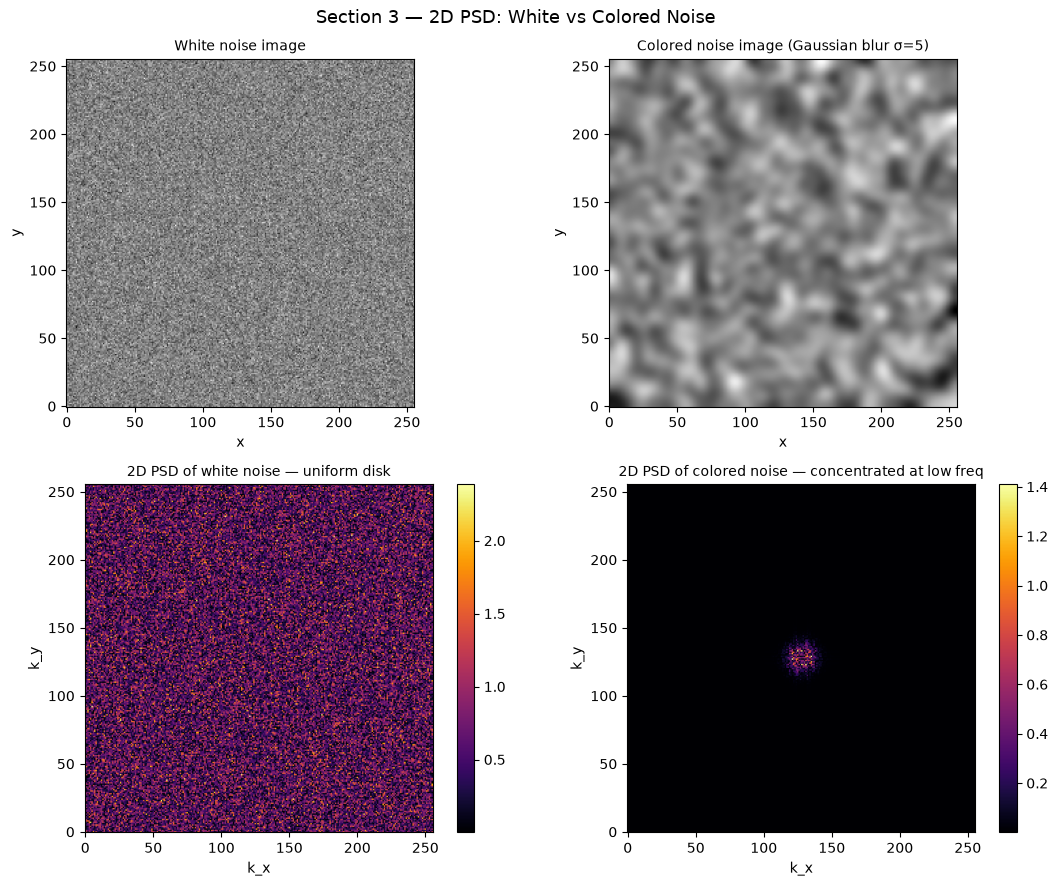

White noise: PSD is uniform across all spatial frequencies.
Colored noise: PSD is bright at the centre (low freq) and dark at edges (high freq).


In [19]:
# --- 2D PSD: white noise image vs Gaussian-blurred (colored) image ---
white_img   = rng.standard_normal((M, M))
colored_img = gaussian_filter(rng.standard_normal((M, M)), sigma=5)

def psd_2d_log(img_):
    ft  = np.fft.fftshift(np.fft.fft2(img_))
    return np.log1p(np.abs(ft) ** 2 / img_.size)

pw2 = psd_2d_log(white_img)
pc2 = psd_2d_log(colored_img)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

axes[0, 0].imshow(white_img,   cmap='gray',    origin='lower')
axes[0, 0].set_title('White noise image', fontsize=10)
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('y')

axes[0, 1].imshow(colored_img, cmap='gray',    origin='lower')
axes[0, 1].set_title('Colored noise image (Gaussian blur σ=5)', fontsize=10)
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('y')

im2 = axes[1, 0].imshow(pw2, cmap='inferno', origin='lower',
                         vmin=pw2.min(), vmax=pw2.max())
axes[1, 0].set_title('2D PSD of white noise — uniform disk', fontsize=10)
axes[1, 0].set_xlabel('k_x')
axes[1, 0].set_ylabel('k_y')
plt.colorbar(im2, ax=axes[1, 0], fraction=0.046)

im3 = axes[1, 1].imshow(pc2, cmap='inferno', origin='lower',
                         vmin=pc2.min(), vmax=pc2.max())
axes[1, 1].set_title('2D PSD of colored noise — concentrated at low freq', fontsize=10)
axes[1, 1].set_xlabel('k_x')
axes[1, 1].set_ylabel('k_y')
plt.colorbar(im3, ax=axes[1, 1], fraction=0.046)

fig.suptitle('Section 3 — 2D PSD: White vs Colored Noise', fontsize=13)
plt.tight_layout()
plt.show()

print("White noise: PSD is uniform across all spatial frequencies.")
print("Colored noise: PSD is bright at the centre (low freq) and dark at edges (high freq).")

---
## セクション 4: 動径 PSD

**等方的**なノイズ（全方向で統計的性質が同じ）では、2D PSD は DC 中心からの動径距離にのみ依存します：

$$r = \sqrt{k_x^2 + k_y^2}$$

同じ半径 $r$ の全画素を角度方向に平均して **動径 PSD（1D）** に圧縮します：

$$\text{PSD}_\text{radial}(r) = \frac{1}{|\{(k_x,k_y)\;:\;\lfloor r \rfloor = r\}|} \sum_{\sqrt{k_x^2+k_y^2}\approx r} |F(k_x,k_y)|^2$$

これが **nb03**（`03_noise_analysis.ipynb`）の `compute_radial_psd` そのものです：

```python
def compute_radial_psd(patch):
    ft    = np.fft.fftshift(np.fft.fft2(patch))
    power = np.abs(ft) ** 2
    r_map = np.sqrt((ys - cy)**2 + (xs - cx)**2).astype(int)
    psd   = np.bincount(r_map.ravel(), weights=power.ravel()) / np.bincount(r_map.ravel())
    freqs = np.arange(len(psd)) / N
    return freqs, psd
```

- **白色ノイズ** → 動径 PSD はフラット（一定値）
- **有色ノイズ** → 動径 PSD は $r$ とともに減少（低周波に集中）

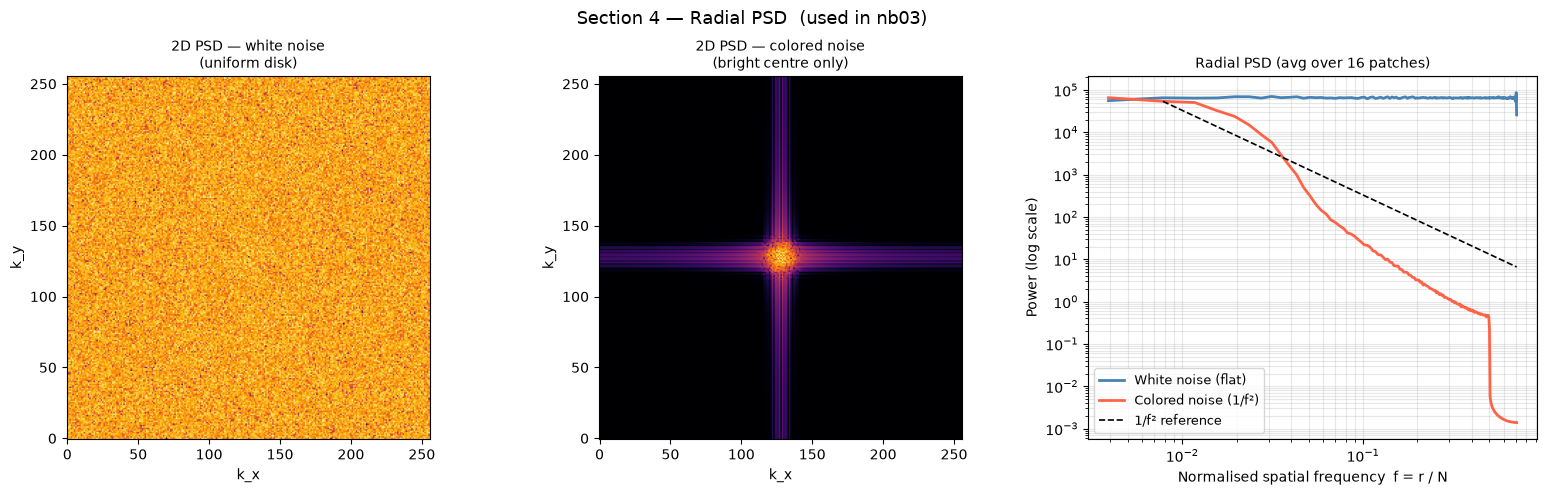

White noise: radial PSD ≈ constant across all radii.
Colored noise: radial PSD falls steeply — most power is at low spatial frequencies.


In [20]:
# --- Radial PSD: white vs colored noise ---

def compute_radial_psd(patch):
    """Compute radial-averaged PSD of a square patch.
    Returns (freqs_normalised, radial_psd) — same as nb03.
    """
    N_  = patch.shape[0]
    ft  = np.fft.fftshift(np.fft.fft2(patch))
    pwr = np.abs(ft) ** 2
    cy, cx  = N_ // 2, N_ // 2
    ys_, xs_ = np.ogrid[:N_, :N_]
    r_map    = np.sqrt((ys_ - cy)**2 + (xs_ - cx)**2).astype(int)
    r_flat   = r_map.ravel()
    p_flat   = pwr.ravel()
    max_r    = r_flat.max() + 1
    radial_psd = np.bincount(r_flat, weights=p_flat) / np.bincount(r_flat)
    freqs      = np.arange(len(radial_psd)) / N_
    return freqs, radial_psd


# Generate multiple patches and average for smoother curves
N_patches = 16
patch_sz  = 256

psds_white  = []
psds_colored = []

for _ in range(N_patches):
    w = rng.standard_normal((patch_sz, patch_sz))
    c = gaussian_filter(rng.standard_normal((patch_sz, patch_sz)), sigma=8)
    _, pw_ = compute_radial_psd(w)
    _, pc_ = compute_radial_psd(c)
    psds_white.append(pw_)
    psds_colored.append(pc_)

freqs, _ = compute_radial_psd(rng.standard_normal((patch_sz, patch_sz)))
mean_white   = np.mean(psds_white,   axis=0)
mean_colored = np.mean(psds_colored, axis=0)

# --- Plot: 2D PSD side-by-side + radial curves ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ex_w = rng.standard_normal((patch_sz, patch_sz))
ex_c = gaussian_filter(rng.standard_normal((patch_sz, patch_sz)), sigma=8)

psd2d_w = np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(ex_w))) ** 2)
psd2d_c = np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(ex_c))) ** 2)

axes[0].imshow(psd2d_w, cmap='inferno', origin='lower')
axes[0].set_title('2D PSD — white noise\n(uniform disk)', fontsize=10)
axes[0].set_xlabel('k_x')
axes[0].set_ylabel('k_y')

axes[1].imshow(psd2d_c, cmap='inferno', origin='lower')
axes[1].set_title('2D PSD — colored noise\n(bright centre only)', fontsize=10)
axes[1].set_xlabel('k_x')
axes[1].set_ylabel('k_y')

axes[2].loglog(freqs[1:], mean_white[1:],   color='steelblue', lw=2,   label='White noise (flat)')
axes[2].loglog(freqs[1:], mean_colored[1:], color='tomato',    lw=2,   label='Colored noise (1/f²)')

# Reference 1/f² slope
f_ref  = freqs[2:]
axes[2].loglog(f_ref, mean_colored[2] * (freqs[2] / f_ref) ** 2,
               'k--', lw=1.2, label='1/f² reference')

axes[2].set_title(f'Radial PSD (avg over {N_patches} patches)', fontsize=10)
axes[2].set_xlabel('Normalised spatial frequency  f = r / N')
axes[2].set_ylabel('Power (log scale)')
axes[2].legend(fontsize=9)
axes[2].grid(True, which='both', alpha=0.3)

fig.suptitle('Section 4 — Radial PSD  (used in nb03)', fontsize=13)
plt.tight_layout()
plt.show()

print("White noise: radial PSD ≈ constant across all radii.")
print("Colored noise: radial PSD falls steeply — most power is at low spatial frequencies.")

---
## まとめ

| 概念 | 定義 | nb03 での使われ方 |
|------|------|-----------------|
| **1D FFT** | $F(k) = \sum_x f(x)\,e^{-2\pi ikx/N}$ | すべてのスペクトル解析の基礎 |
| **2D FFT** | 画像への拡張 | `np.fft.fft2(patch)` |
| **fftshift** | DC 成分を画像中心に移動 | `np.fft.fftshift(...)` |
| **PSD** | $|F(k)|^2 / N$：各周波数のパワー | ノイズパイプライン Step 3 |
| **動径 PSD** | 2D PSD の角度平均 → 1D 曲線 | `compute_radial_psd(patch)` |
| **白色ノイズ** | フラット PSD；画素間に相関なし | ベースライン基準 |
| **有色ノイズ** | 減少する PSD（$1/f^\alpha$）；短距離相関 | TEM 背景ノイズ |
| **ノイズ合成** | FFT 領域で $\sqrt{\text{PSD}}$ フィルタを白色ノイズに適用 | nb03 Step 5 |

### nb03 がこのノートブックと異なる点

- **実際の TEM 画像**（16ビット TIFF）を使用（合成信号ではない）
- ガウスフィルタ差し引きで**高周波残差** $\eta = I - G_\sigma * I$ としてノイズを抽出
- PSD 推定を**背景領域のみ**に限定（ナノシートをマスクアウト）
- 5 枚の画像にわたって動径 PSD 曲線を**集約**してロバストなノイズモデルを構築
- 平均 PSD フィルタを新しい白色ノイズに適用して新しいノイズフレームを**合成**

以上で nb03 をステップごとに理解するために必要な周波数領域のツールがすべて揃いました。